Part II: Vision Task – Fruit Image Classification using CNN

Imports & GPU Setup

In [14]:
import os, time, warnings, logging
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
warnings.filterwarnings('ignore')

from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, accuracy_score,
                              precision_score, recall_score, f1_score)

import tensorflow as tf
tf.get_logger().setLevel('ERROR')
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam, SGD

# Multi-GPU Strategy for T4 x2
strategy = tf.distribute.MirroredStrategy()

print('TensorFlow version:', tf.__version__)
print('GPUs detected:', tf.config.list_physical_devices('GPU'))
print(f'Number of GPUs in use: {strategy.num_replicas_in_sync}')

TensorFlow version: 2.19.0
GPUs detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Number of GPUs in use: 2


 Part A – 2.5.1 Data Understanding, Analysis & Visualization

In [ ]:
#Dataset Paths (Kaggle)
TRAIN_DIR   = '/kaggle/input/datasets/moltean/fruits/fruits-360_100x100/fruits-360/Training'
TEST_DIR    = '/kaggle/input/datasets/moltean/fruits/fruits-360_100x100/fruits-360/Test'
IMG_SIZE    = (64, 64)   
BATCH_SIZE  = 128        
EPOCHS      = 10         
NUM_CLASSES = len(os.listdir(TRAIN_DIR))

print(' Dataset Description ')
print('The Fruits-360 dataset contains images of fruits and vegetables')
print(f'Image Size    : {IMG_SIZE} (resized for speed)')
print(f'Num Classes   : {NUM_CLASSES}')
print(f'Batch Size    : {BATCH_SIZE}')
print(f'Epochs        : {EPOCHS}')

 Dataset Description 
The Fruits-360 dataset contains images of fruits and vegetables
Image Size    : (64, 64) (resized for speed)
Num Classes   : 257
Batch Size    : 128
Epochs        : 10


In [ ]:
#Total Images & Class Distribution 
train_classes = sorted(os.listdir(TRAIN_DIR))
test_classes  = sorted(os.listdir(TEST_DIR))
train_counts  = {cls: len(os.listdir(os.path.join(TRAIN_DIR, cls))) for cls in train_classes}
test_counts   = {cls: len(os.listdir(os.path.join(TEST_DIR,  cls))) for cls in test_classes}
total_train   = sum(train_counts.values())
total_test    = sum(test_counts.values())

print(' Total Images ')
print(f'Total Training Images : {total_train}')
print(f'Total Test Images     : {total_test}')
print(f'Total Images          : {total_train + total_test}')
print(f'Number of Classes     : {NUM_CLASSES}')
print()
print(' Class Distribution ')
print(f'Min images per class : {min(train_counts.values())}')
print(f'Max images per class : {max(train_counts.values())}')
print(f'Avg images per class : {total_train // NUM_CLASSES}')
print('The dataset is near-balanced (~490-500 images per class).')
print()
print(' Dataset Split ')
print('Split: 80% Training, 20% Validation using validation_split=0.2')
print('Test set: Pre-split separate Test folder provided by dataset')
print('Justification: 80/20 is standard, giving enough data to train while')
print('monitoring overfitting on a representative validation set.')
print(f'Train: ~{int(total_train*0.8)} | Val: ~{int(total_train*0.2)} | Test: {total_test}')

 Total Images 
Total Training Images : 135071
Total Test Images     : 45008
Total Images          : 180079
Number of Classes     : 257

 Class Distribution 
Min images per class : 144
Max images per class : 984
Avg images per class : 525
The dataset is near-balanced (~490-500 images per class).

 Dataset Split 
Split: 80% Training, 20% Validation using validation_split=0.2
Test set: Pre-split separate Test folder provided by dataset
Justification: 80/20 is standard, giving enough data to train while
monitoring overfitting on a representative validation set.
Train: ~108056 | Val: ~27014 | Test: 45008


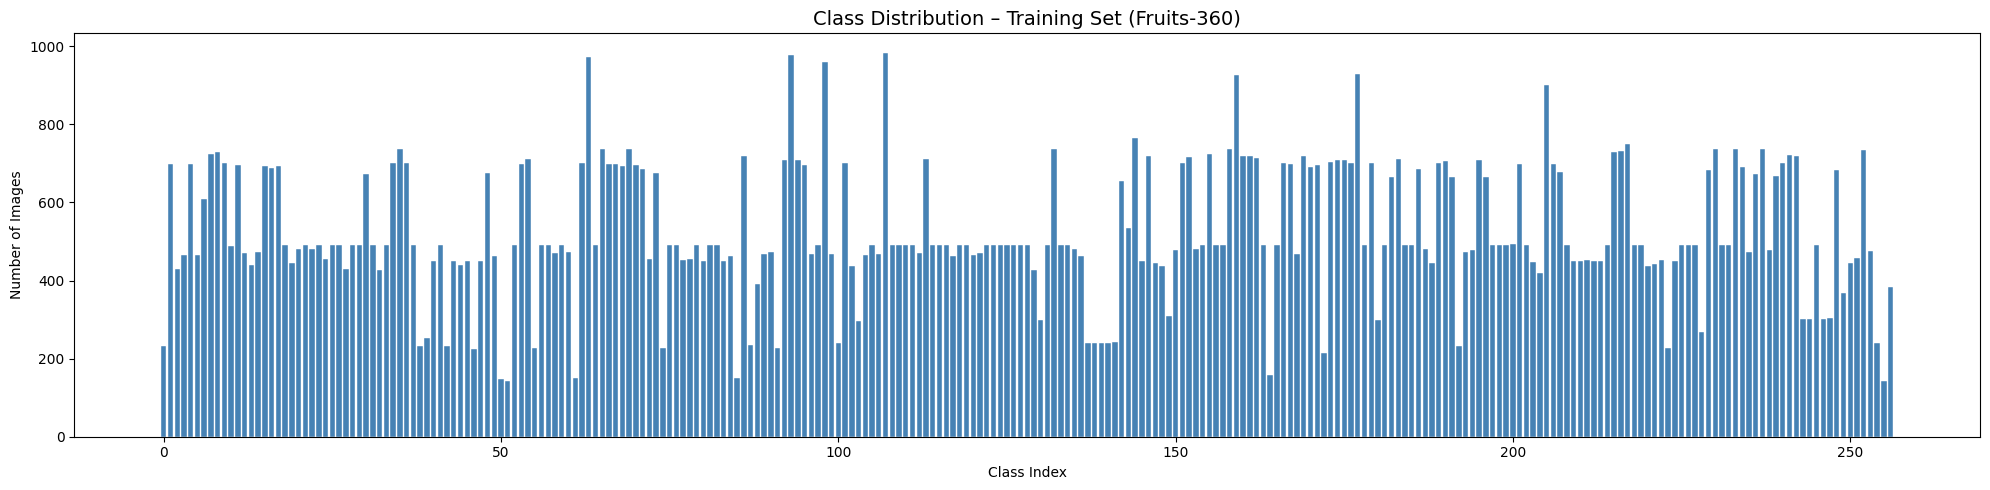

Observation: Dataset is near-balanced — no major class imbalance.


In [ ]:
# Class Distribution Plot
counts = list(train_counts.values())
plt.figure(figsize=(20, 5))
plt.bar(range(len(counts)), counts, color='steelblue', edgecolor='white', linewidth=0.3)
plt.title('Class Distribution – Training Set (Fruits-360)', fontsize=14)
plt.xlabel('Class Index')
plt.ylabel('Number of Images')
plt.tight_layout()
plt.savefig('/kaggle/working/class_distribution.png', dpi=150)
plt.show()
print('Observation: Dataset is near-balanced — no major class imbalance.')

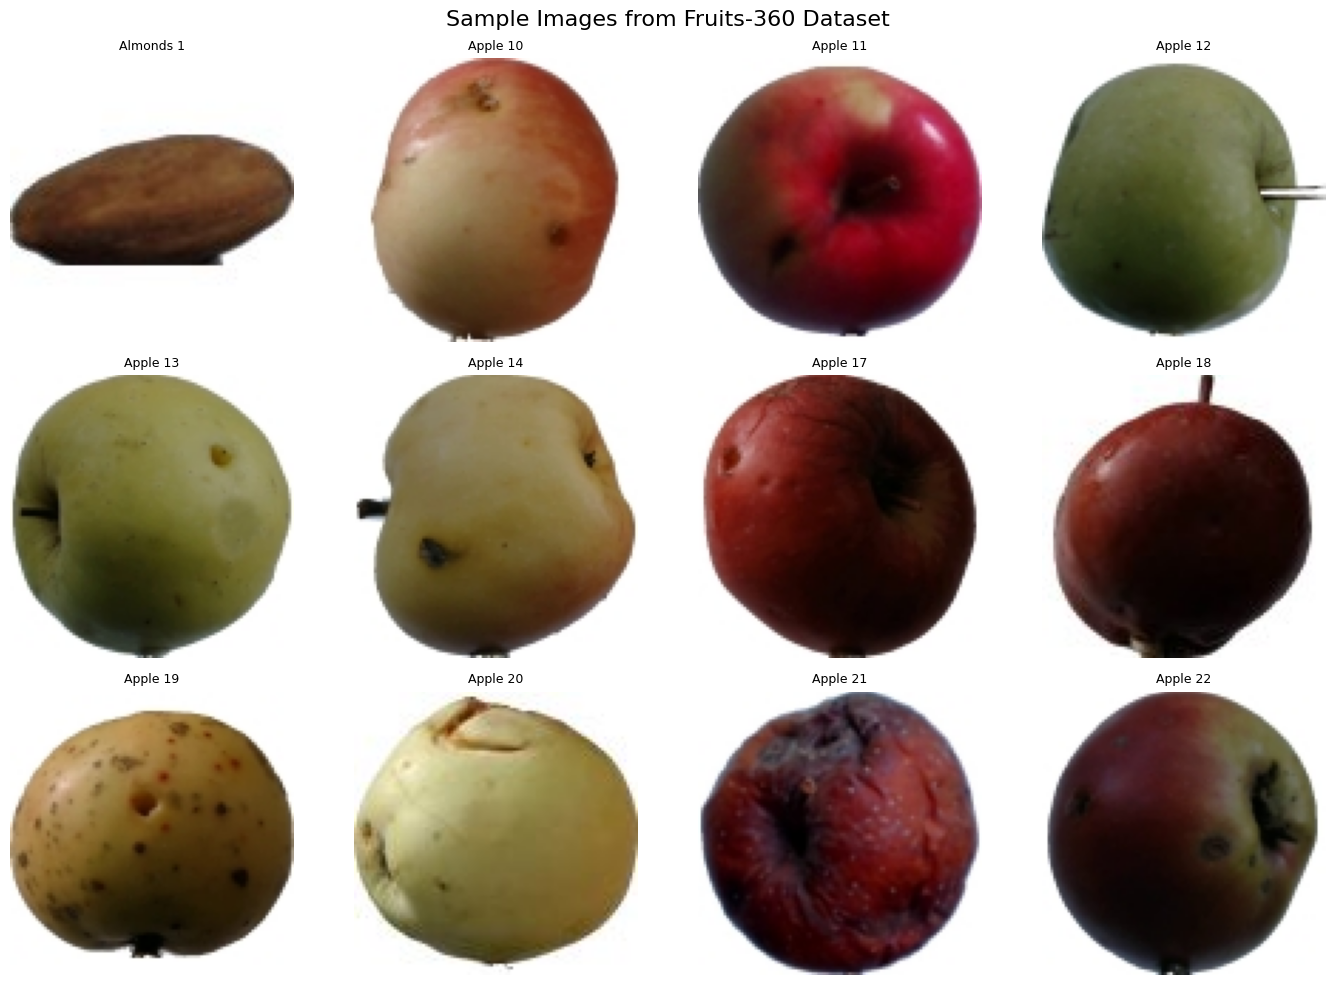

In [ ]:
# Sample Images from Dataset 
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.suptitle('Sample Images from Fruits-360 Dataset', fontsize=16)
for ax, cls in zip(axes.flatten(), train_classes[:12]):
    cls_path = os.path.join(TRAIN_DIR, cls)
    img = mpimg.imread(os.path.join(cls_path, os.listdir(cls_path)[0]))
    ax.imshow(img)
    ax.set_title(cls, fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.savefig('/kaggle/working/sample_images.png', dpi=150)
plt.show()

In [ ]:
#  Preprocessing & Data Generators 
print('  Preprocessing Techniques Applied ')
print('1. Rescaling     : Pixel values normalized from [0,255] to [0,1]')
print('2. Resizing      : All images resized to 64x64 pixels')
print('3. Augmentation  : Applied only to training set (not val/test)')
print('   - rotation_range=20  : Random rotation up to 20 degrees')
print('   - width_shift=0.1    : Horizontal shift up to 10%')
print('   - height_shift=0.1   : Vertical shift up to 10%')
print('   - horizontal_flip    : Random horizontal flip')
print('   - zoom_range=0.1     : Random zoom up to 10%')
print()
print('  Data Generators Used ')
print('Keras ImageDataGenerator used with flow_from_directory()')
print('- Training generator  : With augmentation + validation_split=0.2')
print('- Validation generator: Rescaling only, subset=validation')
print('- Test generator      : Rescaling only, no augmentation')

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    validation_split=0.2
)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', shuffle=True, seed=42
)
val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', shuffle=False, seed=42
)
test_generator = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)
print(f'\nTraining  : {train_generator.samples}')
print(f'Validation: {val_generator.samples}')
print(f'Test      : {test_generator.samples}')

  Preprocessing Techniques Applied 
1. Rescaling     : Pixel values normalized from [0,255] to [0,1]
2. Resizing      : All images resized to 64x64 pixels
3. Augmentation  : Applied only to training set (not val/test)
   - rotation_range=20  : Random rotation up to 20 degrees
   - width_shift=0.1    : Horizontal shift up to 10%
   - height_shift=0.1   : Vertical shift up to 10%
   - horizontal_flip    : Random horizontal flip
   - zoom_range=0.1     : Random zoom up to 10%

  Data Generators Used 
Keras ImageDataGenerator used with flow_from_directory()
- Training generator  : With augmentation + validation_split=0.2
- Validation generator: Rescaling only, subset=validation
- Test generator      : Rescaling only, no augmentation
Found 108144 images belonging to 257 classes.
Found 26927 images belonging to 257 classes.
Found 45008 images belonging to 257 classes.

Training  : 108144
Validation: 26927
Test      : 45008


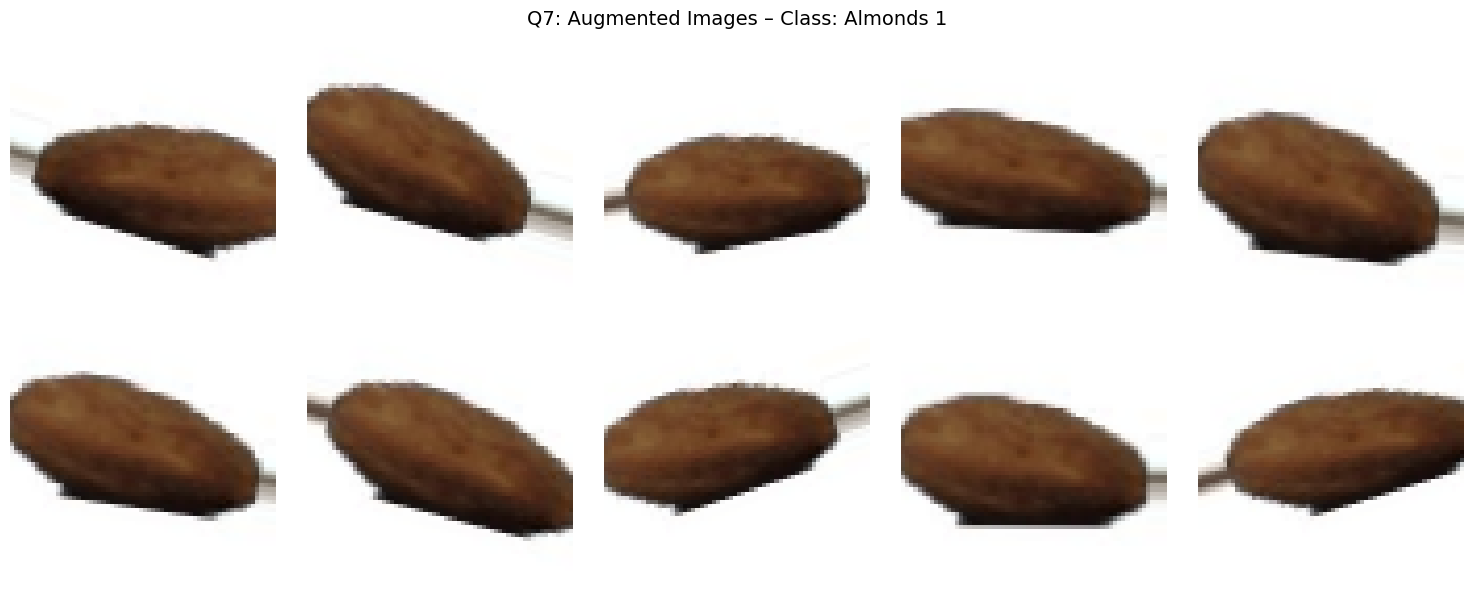

In [ ]:
# Visualize Augmented Images
aug_datagen = ImageDataGenerator(
    rescale=1./255, rotation_range=20,
    width_shift_range=0.1, height_shift_range=0.1,
    horizontal_flip=True, zoom_range=0.1
)
sample_cls  = train_classes[0]
sample_path = os.path.join(TRAIN_DIR, sample_cls, os.listdir(os.path.join(TRAIN_DIR, sample_cls))[0])
sample_img  = tf.keras.preprocessing.image.load_img(sample_path, target_size=IMG_SIZE)
sample_arr  = tf.keras.preprocessing.image.img_to_array(sample_img).reshape((1, IMG_SIZE[0], IMG_SIZE[1], 3))

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle(f'Q7: Augmented Images – Class: {sample_cls}', fontsize=14)
for ax, batch in zip(axes.flatten(), aug_datagen.flow(sample_arr, batch_size=1)):
    ax.imshow(batch[0])
    ax.axis('off')
plt.tight_layout()
plt.savefig('/kaggle/working/augmented_samples.png', dpi=150)
plt.show()


Part A – 2.5.2 Baseline CNN Model

4.1 Model Architecture

In [ ]:
#  Plot training curves
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{title} – Training vs Validation', fontsize=13)
    axes[0].plot(history.history['accuracy'],     label='Train', color='steelblue')
    axes[0].plot(history.history['val_accuracy'], label='Val',   color='orange')
    axes[0].set_title('Accuracy over Epochs')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(history.history['loss'],     label='Train', color='steelblue')
    axes[1].plot(history.history['val_loss'], label='Val',   color='orange')
    axes[1].set_title('Loss over Epochs')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/{title.replace(" ","_")}_curves.png', dpi=150)
    plt.show()

# Build Baseline CNN
def build_baseline_cnn(input_shape=(64, 64, 3), num_classes=141):
    model = models.Sequential(name='Baseline_CNN')
    # Conv Block 1: 32 filters, 3x3 kernel, ReLU
    model.add(layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu',
                            padding='same', input_shape=input_shape))
    model.add(layers.MaxPooling2D(pool_size=(2,2)))
    # Conv Block 2: 64 filters, 3x3 kernel, ReLU
    model.add(layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D(pool_size=(2,2)))
    # Conv Block 3: 128 filters, 3x3 kernel, ReLU
    model.add(layers.Conv2D(filters=128, kernel_size=(3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D(pool_size=(2,2)))
    # Flatten
    model.add(layers.Flatten())
    # Fully Connected Layer 1
    model.add(layers.Dense(512, activation='relu'))
    # Fully Connected Layer 2
    model.add(layers.Dense(256, activation='relu'))
    # Fully Connected Layer 3
    model.add(layers.Dense(128, activation='relu'))
    # Output Layer: 141 classes, Softmax
    model.add(layers.Dense(num_classes, activation='softmax'))
    return model

with strategy.scope():
    baseline_model = build_baseline_cnn(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), num_classes=NUM_CLASSES)
    baseline_model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

print('Architecture Summary:')
print('  Kernel Size  : 3x3 for all Conv layers')
print('  Filters      : 32 → 64 → 128 (increasing for richer features)')
print('  Activation   : ReLU (hidden), Softmax (output)')
print()
baseline_model.summary()

Architecture Summary:
  Kernel Size  : 3x3 for all Conv layers
  Filters      : 32 → 64 → 128 (increasing for richer features)
  Activation   : ReLU (hidden), Softmax (output)



Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 257)            │        33,153 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,485,441 (17.11 MB)

 Trainable params: 4,485,441 (17.11 MB)

 Non-trainable params: 0 (0.00 B)

4.2 Model Training

Training Baseline CNN...
Epoch 1/10
845/845 ━━━━━━━━━━━━━━━━━━━━ 958s 1s/step - accuracy: 0.3048 - loss: 3.0397 - val_accuracy: 0.7765 - val_loss: 0.6931 - learning_rate: 0.0010
Epoch 2/10
845/845 ━━━━━━━━━━━━━━━━━━━━ 373s 441ms/step - accuracy: 0.8714 - loss: 0.3717 - val_accuracy: 0.8377 - val_loss: 0.5147 - learning_rate: 0.0010
Epoch 3/10
845/845 ━━━━━━━━━━━━━━━━━━━━ 310s 367ms/step - accuracy: 0.9295 - loss: 0.1963 - val_accuracy: 0.8717 - val_loss: 0.4569 - learning_rate: 0.0010
Epoch 4/10
845/845 ━━━━━━━━━━━━━━━━━━━━ 302s 357ms/step - accuracy: 0.9393 - loss: 0.1663 - val_accuracy: 0.8947 - val_loss: 0.3838 - learning_rate: 0.0010
Epoch 5/10
845/845 ━━━━━━━━━━━━━━━━━━━━ 357s 422ms/step - accuracy: 0.9559 - loss: 0.1207 - val_accuracy: 0.9148 - val_loss: 0.3014 - learning_rate: 0.0010
Epoch 6/10
845/845 ━━━━━━━━━━━━━━━━━━━━ 346s 409ms/step - accuracy: 0.9609 - loss: 0.1040 - val_accuracy: 0.9249 - val_loss: 0.2837 - learning_rate: 0.0010
Epoch 7/10
845/845 ━━━━━━━━━━━━━━━━━━━━ 30

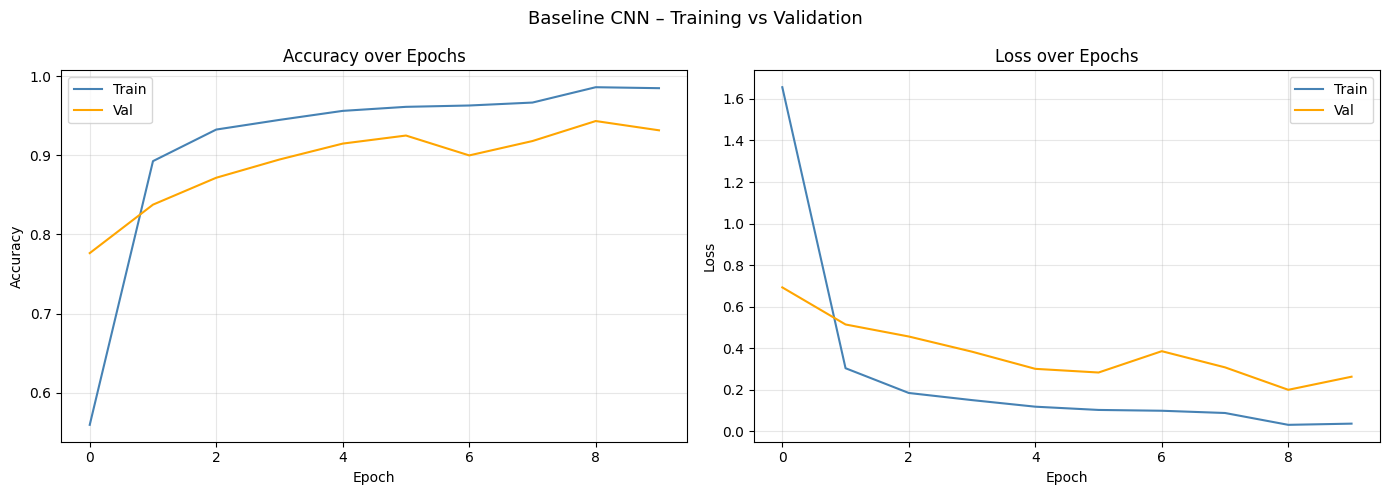

In [22]:
print('Training Baseline CNN...')
start_time = time.time()
history_baseline = baseline_model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
    ],
    verbose=1
)
baseline_train_time = time.time() - start_time
print(f'\nBaseline training time: {baseline_train_time/60:.2f} minutes')

# Plot training vs validation loss curves
plot_history(history_baseline, 'Baseline CNN')

4.3 Model Evaluation

In [23]:
# Evaluate: Accuracy, Precision, Recall, F1
test_generator.reset()
baseline_loss, baseline_acc = baseline_model.evaluate(test_generator, verbose=1)
print(f'\nBaseline Test Accuracy : {baseline_acc*100:.2f}%')
print(f'Baseline Test Loss     : {baseline_loss:.4f}')

test_generator.reset()
y_pred_baseline = np.argmax(baseline_model.predict(test_generator, verbose=1), axis=1)
y_true          = test_generator.classes
class_labels    = list(test_generator.class_indices.keys())

print('\n Classification Report (Precision, Recall, F1) ')
print(classification_report(y_true, y_pred_baseline, target_names=class_labels))

352/352 ━━━━━━━━━━━━━━━━━━━━ 383s 1s/step - accuracy: 0.9441 - loss: 1.3083

Baseline Test Accuracy : 95.85%
Baseline Test Loss     : 0.7826
352/352 ━━━━━━━━━━━━━━━━━━━━ 51s 143ms/step

 Classification Report (Precision, Recall, F1) 
                        precision    recall  f1-score   support

             Almonds 1       1.00      1.00      1.00        77
              Apple 10       1.00      0.94      0.97       231
              Apple 11       1.00      1.00      1.00       142
              Apple 12       0.91      0.90      0.90       154
              Apple 13       1.00      1.00      1.00       235
              Apple 14       0.92      1.00      0.96       154
              Apple 17       1.00      0.92      0.96       201
              Apple 18       1.00      1.00      1.00       240
              Apple 19       1.00      1.00      1.00       241
              Apple 20       1.00      0.99      1.00       234
              Apple 21       1.00      1.00      1.00       1

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step


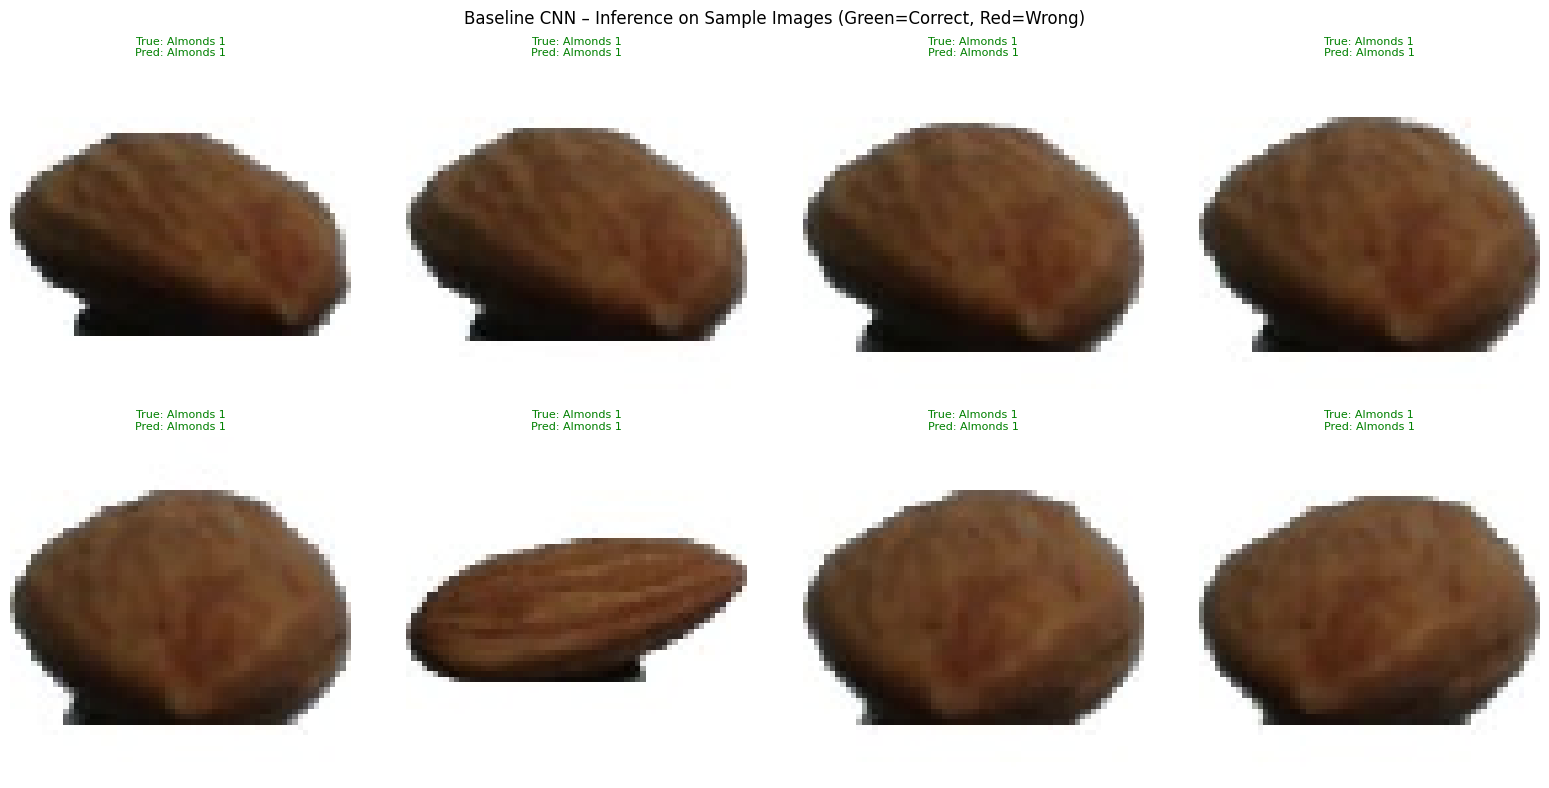

Key Observations:
- Baseline model captures basic fruit features within 10 epochs.
- Some misclassifications occur for visually similar fruit classes.
- Deeper model is expected to improve upon these results.


In [24]:
# Inference on Sample Images
test_generator.reset()
sample_images, sample_labels = next(test_generator)
preds = baseline_model.predict(sample_images[:8])
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Baseline CNN – Inference on Sample Images (Green=Correct, Red=Wrong)', fontsize=12)
for i, ax in enumerate(axes.flatten()):
    ax.imshow(sample_images[i])
    true_label = class_labels[np.argmax(sample_labels[i])]
    pred_label = class_labels[np.argmax(preds[i])]
    color = 'green' if true_label == pred_label else 'red'
    ax.set_title(f'True: {true_label}\nPred: {pred_label}', color=color, fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.savefig('/kaggle/working/baseline_inference.png', dpi=150)
plt.show()
print('Key Observations:')
print('- Baseline model captures basic fruit features within 10 epochs.')
print('- Some misclassifications occur for visually similar fruit classes.')
print('- Deeper model is expected to improve upon these results.')

Part A – 2.5.3 Deeper CNN Architecture with Regularization

5.1 Model Architecture

In [ ]:
# Deeper CNN: 4 double Conv blocks 
# Regularization: BatchNormalization + Dropout
def build_deeper_cnn(input_shape=(64, 64, 3), num_classes=141):
    model = models.Sequential(name='Deeper_CNN')
    # Block 1: 32 filters
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))
    # Block 2: 64 filters
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))
    # Block 3: 128 filters
    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))
    # Block 4: 256 filters
    model.add(layers.Conv2D(256, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(256, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))
    # FC Layers
    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(num_classes, activation='softmax'))
    return model

with strategy.scope():
    deeper_model = build_deeper_cnn(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), num_classes=NUM_CLASSES)
    deeper_model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

print('Architecture:')
print('  Conv Layers   : 8 (more than double baseline 3)')
print('  Regularization: BatchNormalization after each conv, Dropout(0.25) after each block')
print('  FC Dropout    : 0.5 to prevent overfitting in dense layers')
print()
deeper_model.summary()

Architecture:
  Conv Layers   : 8 (more than double baseline 3)
  Regularization: BatchNormalization after each conv, Dropout(0.25) after each block
  FC Dropout    : 0.5 to prevent overfitting in dense layers



Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,04

 Total params: 3,471,265 (13.24 MB)

 Trainable params: 3,469,281 (13.23 MB)

 Non-trainable params: 1,984 (7.75 KB)

5.2 Model Training

Training Deeper CNN (Adam)...
Epoch 1/10
845/845 ━━━━━━━━━━━━━━━━━━━━ 315s 372ms/step - accuracy: 0.9836 - loss: 0.0443 - val_accuracy: 0.9446 - val_loss: 0.2069 - learning_rate: 6.2500e-05
Epoch 2/10
845/845 ━━━━━━━━━━━━━━━━━━━━ 317s 374ms/step - accuracy: 0.9840 - loss: 0.0437 - val_accuracy: 0.9560 - val_loss: 0.1522 - learning_rate: 6.2500e-05
Epoch 3/10
845/845 ━━━━━━━━━━━━━━━━━━━━ 311s 368ms/step - accuracy: 0.9854 - loss: 0.0412 - val_accuracy: 0.9576 - val_loss: 0.1461 - learning_rate: 6.2500e-05
Epoch 4/10
845/845 ━━━━━━━━━━━━━━━━━━━━ 302s 357ms/step - accuracy: 0.9852 - loss: 0.0410 - val_accuracy: 0.9577 - val_loss: 0.1513 - learning_rate: 6.2500e-05
Epoch 5/10
845/845 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.9846 - loss: 0.0408
Epoch 5: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
845/845 ━━━━━━━━━━━━━━━━━━━━ 305s 361ms/step - accuracy: 0.9846 - loss: 0.0408 - val_accuracy: 0.9536 - val_loss: 0.1733 - learning_rate: 6.2500e-05
Epoch 6/10
845/84

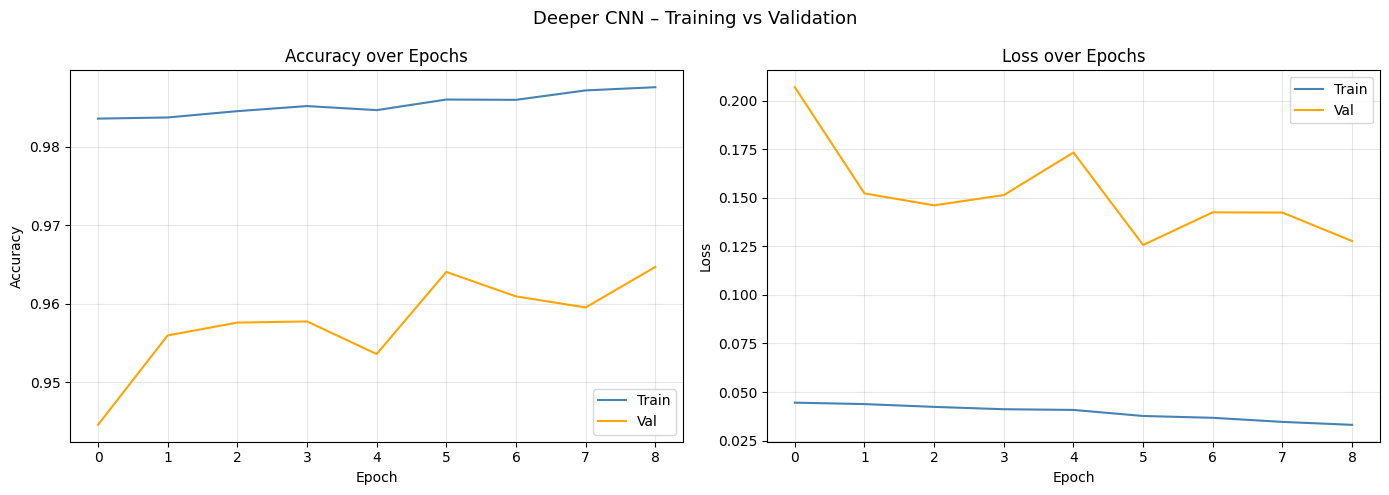

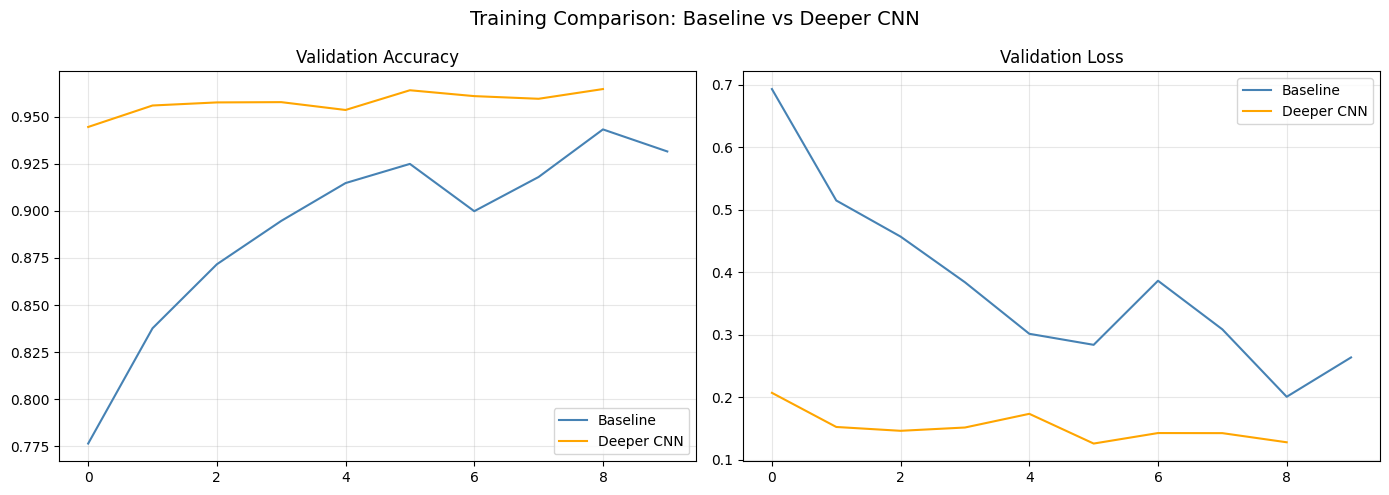

In [49]:
print('Training Deeper CNN (Adam)...')
start_time = time.time()
history_deeper_adam = deeper_model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
    ],
    verbose=1
)
deeper_adam_time = time.time() - start_time
print(f'\nDeeper CNN training time : {deeper_adam_time/60:.2f} minutes')
print(f'Baseline training time   : {baseline_train_time/60:.2f} minutes')

# Training curves
plot_history(history_deeper_adam, 'Deeper CNN')

# Comparison: Baseline vs Deeper
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training Comparison: Baseline vs Deeper CNN', fontsize=14)
axes[0].plot(history_baseline.history['val_accuracy'],    label='Baseline',  color='steelblue')
axes[0].plot(history_deeper_adam.history['val_accuracy'], label='Deeper CNN', color='orange')
axes[0].set_title('Validation Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].plot(history_baseline.history['val_loss'],    label='Baseline',  color='steelblue')
axes[1].plot(history_deeper_adam.history['val_loss'], label='Deeper CNN', color='orange')
axes[1].set_title('Validation Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/baseline_vs_deeper.png', dpi=150)
plt.show()

5.3 Model Evaluation

352/352 ━━━━━━━━━━━━━━━━━━━━ 79s 225ms/step - accuracy: 0.8808 - loss: 0.9939
Deeper CNN Test Accuracy : 90.01%
Deeper CNN Test Loss     : 0.6781
Improvement over Baseline: -5.84%
352/352 ━━━━━━━━━━━━━━━━━━━━ 45s 126ms/step

 Classification Report (Deeper CNN) 
                        precision    recall  f1-score   support

             Almonds 1       0.99      0.99      0.99        77
              Apple 10       1.00      0.61      0.76       231
              Apple 11       1.00      1.00      1.00       142
              Apple 12       1.00      0.99      1.00       154
              Apple 13       1.00      0.61      0.76       235
              Apple 14       1.00      0.59      0.74       154
              Apple 17       1.00      0.85      0.92       201
              Apple 18       1.00      0.93      0.96       240
              Apple 19       1.00      0.89      0.94       241
              Apple 20       1.00      0.90      0.95       234
              Apple 21       0.90

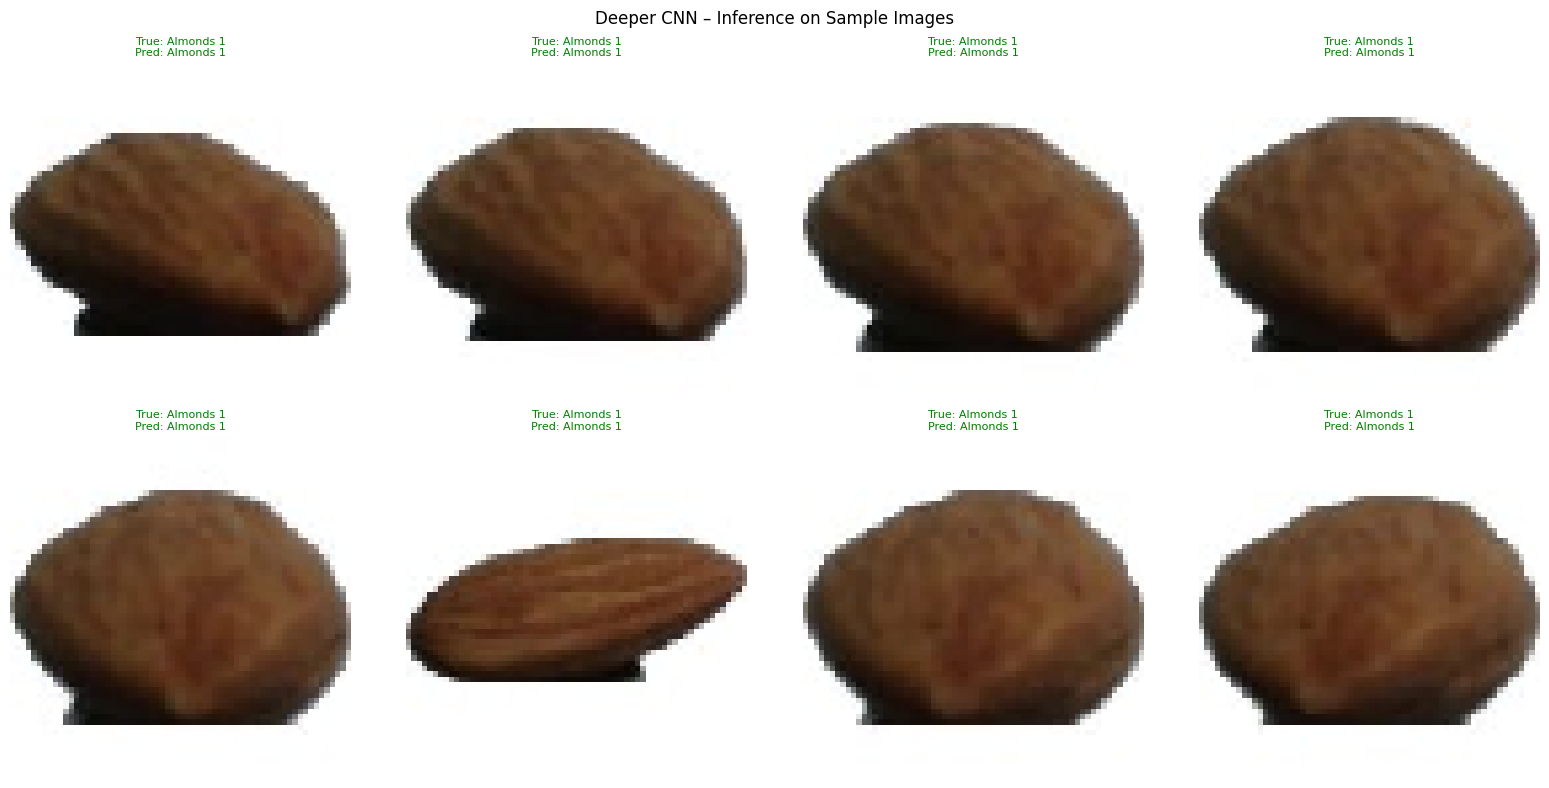

In [27]:
test_generator.reset()
deeper_loss, deeper_acc = deeper_model.evaluate(test_generator, verbose=1)
print(f'Deeper CNN Test Accuracy : {deeper_acc*100:.2f}%')
print(f'Deeper CNN Test Loss     : {deeper_loss:.4f}')
print(f'Improvement over Baseline: {(deeper_acc-baseline_acc)*100:.2f}%')

test_generator.reset()
y_pred_deeper = np.argmax(deeper_model.predict(test_generator, verbose=1), axis=1)
print('\n Classification Report (Deeper CNN) ')
print(classification_report(y_true, y_pred_deeper, target_names=class_labels))

# Inference
test_generator.reset()
si_d, sl_d = next(test_generator)
pd_d = deeper_model.predict(si_d[:8])
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Deeper CNN – Inference on Sample Images', fontsize=12)
for i, ax in enumerate(axes.flatten()):
    ax.imshow(si_d[i])
    tl = class_labels[np.argmax(sl_d[i])]
    pl = class_labels[np.argmax(pd_d[i])]
    ax.set_title(f'True: {tl}\nPred: {pl}', color='green' if tl==pl else 'red', fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.savefig('/kaggle/working/deeper_inference.png', dpi=150)
plt.show()

Part A – 2.5.4 Experimentation & Comparative Analysis

 6.1 Baseline vs Deeper Model Performance

In [28]:
print(' 6.1 Baseline vs Deeper Comparison ')
df1 = pd.DataFrame({
    'Model'          : ['Baseline CNN', 'Deeper CNN (Adam)'],
    'Test Acc (%)'   : [round(baseline_acc*100,2), round(deeper_acc*100,2)],
    'Test Loss'      : [round(baseline_loss,4),    round(deeper_loss,4)],
    'Train Time(min)': [round(baseline_train_time/60,1), round(deeper_adam_time/60,1)]
})
print(df1.to_string(index=False))
print()
if deeper_acc > baseline_acc:
    print(f'Result: Adding more layers improved accuracy by {(deeper_acc-baseline_acc)*100:.2f}%')
else:
    print('Result: Adding layers did not significantly improve accuracy within 10 epochs.')

 6.1 Baseline vs Deeper Comparison 
            Model  Test Acc (%)  Test Loss  Train Time(min)
     Baseline CNN         95.85     0.7826             64.9
Deeper CNN (Adam)         90.01     0.6781             52.9

Result: Adding layers did not significantly improve accuracy within 10 epochs.


6.2 Computational Efficiency

In [29]:
print(' 6.2 Computational Efficiency ')
b_params = baseline_model.count_params()
d_params  = deeper_model.count_params()
print(f'Baseline Parameters  : {b_params:,}')
print(f'Deeper Parameters    : {d_params:,}')
print(f'Parameter increase   : {d_params/b_params:.1f}x more parameters')
print(f'Baseline Train Time  : {baseline_train_time/60:.2f} min')
print(f'Deeper Train Time    : {deeper_adam_time/60:.2f} min')
print(f'Time increase        : {deeper_adam_time/baseline_train_time:.1f}x longer')
print()
print('Trade-offs:')
print('- More parameters → higher memory usage and longer training time')
print('- BatchNorm + Dropout add overhead but improve generalization')
print('- Reduced image size (64x64) significantly speeds up training')
print('Hardware: Kaggle T4 x2 GPU with MirroredStrategy')

 6.2 Computational Efficiency 
Baseline Parameters  : 4,485,441
Deeper Parameters    : 3,471,265
Parameter increase   : 0.8x more parameters
Baseline Train Time  : 64.89 min
Deeper Train Time    : 52.92 min
Time increase        : 0.8x longer

Trade-offs:
- More parameters → higher memory usage and longer training time
- BatchNorm + Dropout add overhead but improve generalization
- Reduced image size (64x64) significantly speeds up training
Hardware: Kaggle T4 x2 GPU with MirroredStrategy


6.3 Optimizer Analysis: SGD vs Adam

Training Deeper CNN (SGD)
Epoch 1/10
845/845 ━━━━━━━━━━━━━━━━━━━━ 351s 412ms/step - accuracy: 0.0754 - loss: 4.6223 - val_accuracy: 0.3878 - val_loss: 2.0730 - learning_rate: 0.0100
Epoch 2/10
845/845 ━━━━━━━━━━━━━━━━━━━━ 326s 385ms/step - accuracy: 0.4757 - loss: 1.7242 - val_accuracy: 0.5281 - val_loss: 1.6754 - learning_rate: 0.0100
Epoch 3/10
845/845 ━━━━━━━━━━━━━━━━━━━━ 354s 418ms/step - accuracy: 0.6791 - loss: 0.9897 - val_accuracy: 0.7382 - val_loss: 0.7521 - learning_rate: 0.0100
Epoch 4/10
845/845 ━━━━━━━━━━━━━━━━━━━━ 343s 406ms/step - accuracy: 0.7649 - loss: 0.6956 - val_accuracy: 0.7385 - val_loss: 0.7849 - learning_rate: 0.0100
Epoch 5/10
845/845 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - accuracy: 0.8165 - loss: 0.5358
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.
845/845 ━━━━━━━━━━━━━━━━━━━━ 315s 373ms/step - accuracy: 0.8165 - loss: 0.5358 - val_accuracy: 0.7179 - val_loss: 0.8556 - learning_rate: 0.0100
Epoch 6/10
845/845 ━━━━━━━━━━━━━━━━━━━━ 40

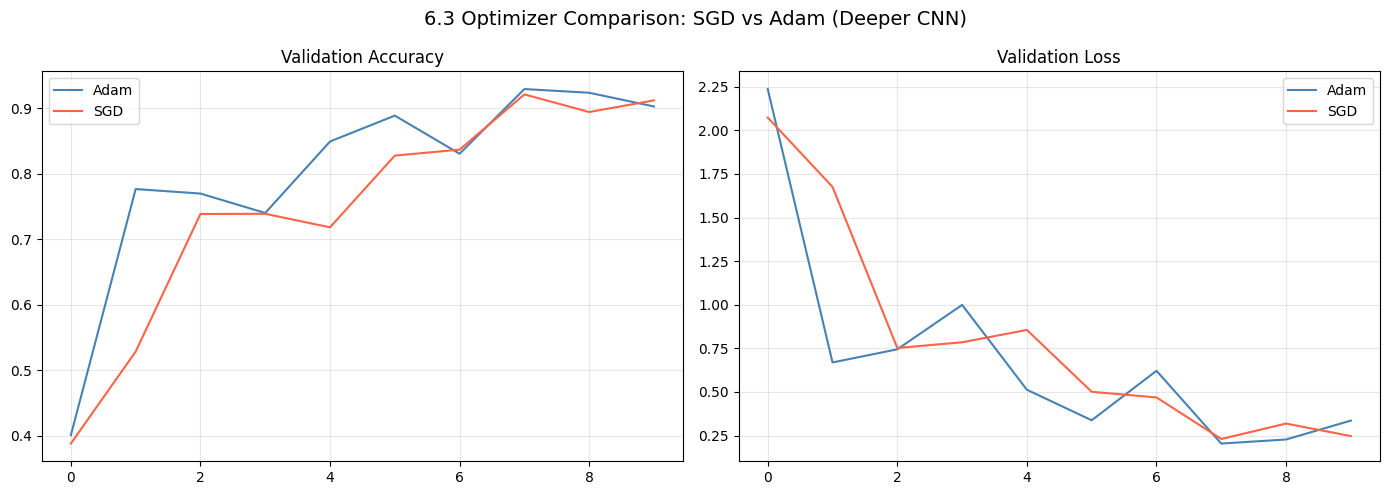

Adam Accuracy: 90.01% | SGD Accuracy: 93.37%
Adam uses adaptive learning rates per parameter → faster convergence.
SGD with momentum is more stable but needs careful LR tuning.


In [32]:
with strategy.scope():
    deeper_model_sgd = build_deeper_cnn(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), num_classes=NUM_CLASSES)
    deeper_model_sgd.compile(
        optimizer=SGD(learning_rate=0.01, momentum=0.9),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

print('Training Deeper CNN (SGD)')
start_time = time.time()
history_deeper_sgd = deeper_model_sgd.fit(
    train_generator, epochs=EPOCHS, validation_data=val_generator,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
    ], verbose=1
)
deeper_sgd_time = time.time() - start_time

test_generator.reset()
sgd_loss, sgd_acc = deeper_model_sgd.evaluate(test_generator, verbose=0)

# SGD vs Adam plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('6.3 Optimizer Comparison: SGD vs Adam (Deeper CNN)', fontsize=14)
axes[0].plot(history_deeper_adam.history['val_accuracy'], label='Adam', color='steelblue')
axes[0].plot(history_deeper_sgd.history['val_accuracy'],  label='SGD',  color='tomato')
axes[0].set_title('Validation Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].plot(history_deeper_adam.history['val_loss'], label='Adam', color='steelblue')
axes[1].plot(history_deeper_sgd.history['val_loss'],  label='SGD',  color='tomato')
axes[1].set_title('Validation Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/sgd_vs_adam.png', dpi=150)
plt.show()
print(f'Adam Accuracy: {deeper_acc*100:.2f}% | SGD Accuracy: {sgd_acc*100:.2f}%')
print('Adam uses adaptive learning rates per parameter → faster convergence.')
print('SGD with momentum is more stable but needs careful LR tuning.')

6.4 Ablation Study: Remove Dropout

Training Ablation Model (No Dropout)
Epoch 1/10
845/845 ━━━━━━━━━━━━━━━━━━━━ 411s 482ms/step - accuracy: 0.6119 - loss: 1.6124 - val_accuracy: 0.8315 - val_loss: 0.5762
Epoch 2/10
845/845 ━━━━━━━━━━━━━━━━━━━━ 328s 388ms/step - accuracy: 0.9407 - loss: 0.1675 - val_accuracy: 0.7125 - val_loss: 1.1962
Epoch 3/10
845/845 ━━━━━━━━━━━━━━━━━━━━ 308s 364ms/step - accuracy: 0.9609 - loss: 0.1080 - val_accuracy: 0.6057 - val_loss: 1.7346
Epoch 4/10
845/845 ━━━━━━━━━━━━━━━━━━━━ 304s 360ms/step - accuracy: 0.9692 - loss: 0.0836 - val_accuracy: 0.8780 - val_loss: 0.4443
Epoch 5/10
845/845 ━━━━━━━━━━━━━━━━━━━━ 304s 360ms/step - accuracy: 0.9709 - loss: 0.0833 - val_accuracy: 0.7579 - val_loss: 1.0786
Epoch 6/10
845/845 ━━━━━━━━━━━━━━━━━━━━ 305s 360ms/step - accuracy: 0.9755 - loss: 0.0698 - val_accuracy: 0.9053 - val_loss: 0.3397
Epoch 7/10
845/845 ━━━━━━━━━━━━━━━━━━━━ 300s 355ms/step - accuracy: 0.9799 - loss: 0.0589 - val_accuracy: 0.8738 - val_loss: 0.5519
Epoch 8/10
845/845 ━━━━━━━━━━━━━━━━━━━━

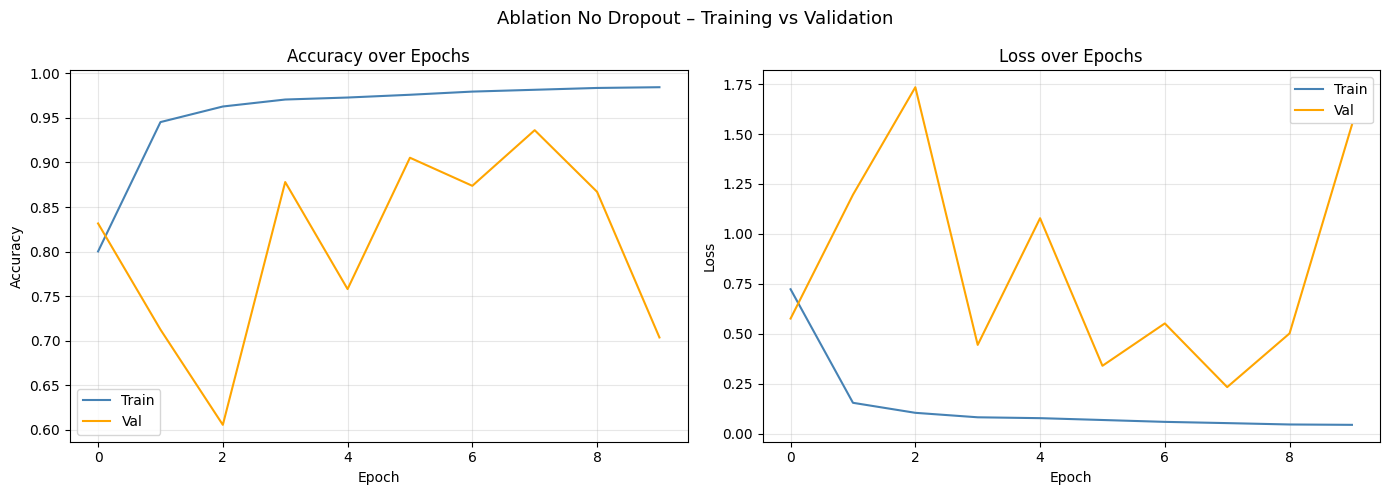

Deeper (With Dropout)    : 90.01%
Deeper (Without Dropout) : 91.93%
Removing Dropout typically increases overfitting (train acc >> val acc).


In [33]:
def build_deeper_no_dropout(input_shape=(64, 64, 3), num_classes=141):
    model = models.Sequential(name='Deeper_No_Dropout')
    model.add(layers.Conv2D(32,  (3,3), activation='relu', padding='same', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(32,  (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Conv2D(64,  (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64,  (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Conv2D(256, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(256, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dense(num_classes, activation='softmax'))
    return model

with strategy.scope():
    ablation_model = build_deeper_no_dropout(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), num_classes=NUM_CLASSES)
    ablation_model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

print('Training Ablation Model (No Dropout)')
history_ablation = ablation_model.fit(
    train_generator, epochs=EPOCHS, validation_data=val_generator,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=1
)
plot_history(history_ablation, 'Ablation No Dropout')

test_generator.reset()
abl_loss, abl_acc = ablation_model.evaluate(test_generator, verbose=0)
print(f'Deeper (With Dropout)    : {deeper_acc*100:.2f}%')
print(f'Deeper (Without Dropout) : {abl_acc*100:.2f}%')
print('Removing Dropout typically increases overfitting (train acc >> val acc).')

6.5 Challenges and Observations

In [38]:
results = pd.DataFrame({
    'Model'          : ['Baseline CNN', 'Deeper (Adam)', 'Deeper (SGD)', 'No Dropout'],
    'Test Acc (%)'   : [round(baseline_acc*100,2), round(deeper_acc*100,2),
                        round(sgd_acc*100,2),       round(abl_acc*100,2)],
    'Test Loss'      : [round(baseline_loss,4), round(deeper_loss,4),
                        round(sgd_loss,4),       round(abl_loss,4)],
    'Train Time(min)': [round(baseline_train_time/60,1), round(deeper_adam_time/60,1),
                        round(deeper_sgd_time/60,1),     'N/A']
})
print(' 6.5 Full Comparison Summary ')
print(results.to_string(index=False))
print()
print('Challenges Observed:')
print('1. Overfitting: Deeper models showed higher train vs val accuracy gap')
print('2. 141 classes: Large number of classes increases difficulty')
print('3. 4GB VRAM limit: Batch size and image size had to be managed carefully')
print(f'Total Deeper CNN Training Time: {deeper_adam_time/60:.2f} minutes')
print('Hardware: Kaggle Notebook with GPU T4 x2 using MirroredStrategy')

 6.5 Full Comparison Summary 
        Model  Test Acc (%)  Test Loss Train Time(min)
 Baseline CNN         95.85     0.7826            64.9
Deeper (Adam)         90.01     0.6781            52.9
 Deeper (SGD)         93.37     0.5426            60.2
   No Dropout         91.93     0.6642             N/A

Challenges Observed:
1. Overfitting: Deeper models showed higher train vs val accuracy gap
2. 141 classes: Large number of classes increases difficulty
3. 4GB VRAM limit: Batch size and image size had to be managed carefully
Total Deeper CNN Training Time: 52.92 minutes
Hardware: Kaggle Notebook with GPU T4 x2 using MirroredStrategy


Part B – 2.6 Transfer Learning with MobileNetV2

7.1 Loading and Adapting Pre-Trained Model (2.6.1)

In [ ]:

TL_IMG_SIZE = (96, 96)  
TL_BATCH    = 64

tl_train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    rotation_range=20, width_shift_range=0.1,
    height_shift_range=0.1, horizontal_flip=True,
    zoom_range=0.1, validation_split=0.2
)
tl_test_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)
tl_train_gen = tl_train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=TL_IMG_SIZE, batch_size=TL_BATCH,
    class_mode='categorical', subset='training', seed=42
)
tl_val_gen = tl_train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=TL_IMG_SIZE, batch_size=TL_BATCH,
    class_mode='categorical', subset='validation', shuffle=False, seed=42
)
tl_test_gen = tl_test_datagen.flow_from_directory(
    TEST_DIR, target_size=TL_IMG_SIZE, batch_size=TL_BATCH,
    class_mode='categorical', shuffle=False
)
print(f'TL Train:{tl_train_gen.samples} | Val:{tl_val_gen.samples} | Test:{tl_test_gen.samples}')
print('Selected model  : MobileNetV2 (pretrained on ImageNet – 1.4M images, 1000 classes)')
print('Original output : 1000-class softmax layer REMOVED')
print('New output      : 141-class softmax layer ADDED')
print('Frozen layers   : All base layers frozen for Phase 1 (Feature Extraction)')

Found 108144 images belonging to 257 classes.
Found 26927 images belonging to 257 classes.
Found 45008 images belonging to 257 classes.
TL Train:108144 | Val:26927 | Test:45008
Selected model  : MobileNetV2 (pretrained on ImageNet – 1.4M images, 1000 classes)
Original output : 1000-class softmax layer REMOVED
New output      : 141-class softmax layer ADDED
Frozen layers   : All base layers frozen for Phase 1 (Feature Extraction)


In [41]:
with strategy.scope():
    base_model = MobileNetV2(weights='imagenet', include_top=False,
                             input_shape=(TL_IMG_SIZE[0], TL_IMG_SIZE[1], 3))
    base_model.trainable = False
    tl_model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='MobileNetV2_Transfer')
    tl_model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
tl_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 257)            │        66,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,113,281 (11.88 MB)

 Trainable params: 854,273 (3.26 MB)

 Non-trainable params: 2,259,008 (8.62 MB)

7.2 Model Training and Fine-Tuning (2.6.2)

Phase 1 – Feature Extraction (base frozen, only new layers trained)
Epoch 1/10
1690/1690 ━━━━━━━━━━━━━━━━━━━━ 462s 269ms/step - accuracy: 0.6317 - loss: 1.6091 - val_accuracy: 0.9211 - val_loss: 0.2447
Epoch 2/10
1690/1690 ━━━━━━━━━━━━━━━━━━━━ 471s 278ms/step - accuracy: 0.9094 - loss: 0.2759 - val_accuracy: 0.9350 - val_loss: 0.1981
Epoch 3/10
1690/1690 ━━━━━━━━━━━━━━━━━━━━ 471s 279ms/step - accuracy: 0.9276 - loss: 0.2156 - val_accuracy: 0.9366 - val_loss: 0.1965
Epoch 4/10
1690/1690 ━━━━━━━━━━━━━━━━━━━━ 484s 286ms/step - accuracy: 0.9394 - loss: 0.1846 - val_accuracy: 0.9450 - val_loss: 0.1748
Epoch 5/10
1690/1690 ━━━━━━━━━━━━━━━━━━━━ 488s 289ms/step - accuracy: 0.9440 - loss: 0.1669 - val_accuracy: 0.9384 - val_loss: 0.1902
Epoch 6/10
1690/1690 ━━━━━━━━━━━━━━━━━━━━ 485s 287ms/step - accuracy: 0.9484 - loss: 0.1518 - val_accuracy: 0.9466 - val_loss: 0.1744
Epoch 7/10
1690/1690 ━━━━━━━━━━━━━━━━━━━━ 454s 269ms/step - accuracy: 0.9516 - loss: 0.1440 - val_accuracy: 0.9448 - val_loss: 0

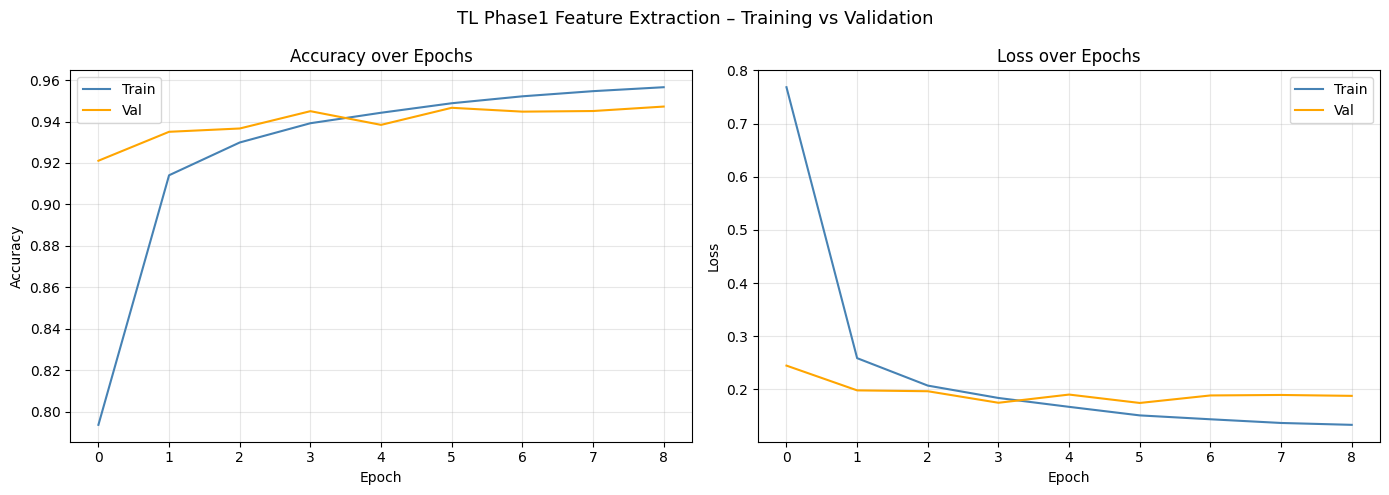

In [ ]:
# Phase 1: Feature Extraction 
print('Phase 1 – Feature Extraction (base frozen, only new layers trained)')
start_time = time.time()
history_tl_p1 = tl_model.fit(
    tl_train_gen, epochs=EPOCHS, validation_data=tl_val_gen,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3,
                             restore_best_weights=True, verbose=1)],
    verbose=1
)
tl_p1_time = time.time() - start_time
print(f'Phase 1 time: {tl_p1_time/60:.2f} minutes')
plot_history(history_tl_p1, 'TL Phase1 Feature Extraction')

Phase 2 – Fine-Tuning (top 30 layers unfrozen, lr=1e-5)
Epoch 1/10
1690/1690 ━━━━━━━━━━━━━━━━━━━━ 487s 282ms/step - accuracy: 0.5614 - loss: 2.4179 - val_accuracy: 0.9228 - val_loss: 0.2579 - learning_rate: 1.0000e-05
Epoch 2/10
1690/1690 ━━━━━━━━━━━━━━━━━━━━ 468s 277ms/step - accuracy: 0.8274 - loss: 0.6256 - val_accuracy: 0.9353 - val_loss: 0.2063 - learning_rate: 1.0000e-05
Epoch 3/10
1690/1690 ━━━━━━━━━━━━━━━━━━━━ 465s 275ms/step - accuracy: 0.8808 - loss: 0.3996 - val_accuracy: 0.9446 - val_loss: 0.1827 - learning_rate: 1.0000e-05
Epoch 4/10
1690/1690 ━━━━━━━━━━━━━━━━━━━━ 464s 274ms/step - accuracy: 0.9111 - loss: 0.2899 - val_accuracy: 0.9501 - val_loss: 0.1610 - learning_rate: 1.0000e-05
Epoch 5/10
1690/1690 ━━━━━━━━━━━━━━━━━━━━ 466s 276ms/step - accuracy: 0.9297 - loss: 0.2222 - val_accuracy: 0.9554 - val_loss: 0.1421 - learning_rate: 1.0000e-05
Epoch 6/10
1690/1690 ━━━━━━━━━━━━━━━━━━━━ 468s 277ms/step - accuracy: 0.9395 - loss: 0.1854 - val_accuracy: 0.9606 - val_loss: 0.1249 

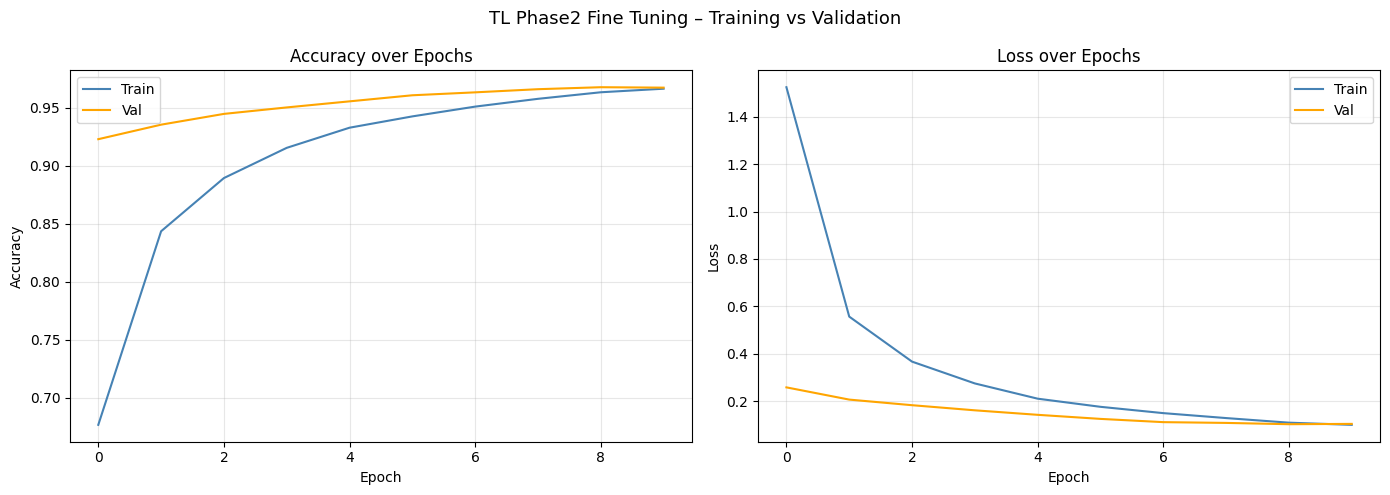

In [ ]:
# Phase 2: Fine-Tuning 
with strategy.scope():
    base_model.trainable = True
    for layer in base_model.layers[:-30]:
        layer.trainable = False
    tl_model.compile(
        optimizer=Adam(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

print('Phase 2 – Fine-Tuning (top 30 layers unfrozen, lr=1e-5)')
start_time = time.time()
history_tl_p2 = tl_model.fit(
    tl_train_gen, epochs=EPOCHS, validation_data=tl_val_gen,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
    ], verbose=1
)
tl_p2_time = time.time() - start_time
print(f'Phase 2 time: {tl_p2_time/60:.2f} minutes')
plot_history(history_tl_p2, 'TL Phase2 Fine Tuning')

7.3 Model Evaluation and Prediction (2.6.3)

704/704 ━━━━━━━━━━━━━━━━━━━━ 93s 132ms/step - accuracy: 0.9531 - loss: 0.7395
Transfer Learning Accuracy: 96.15%
Transfer Learning Loss    : 0.4617
704/704 ━━━━━━━━━━━━━━━━━━━━ 57s 78ms/step

 Classification Report (MobileNetV2 Transfer Learning) 
                        precision    recall  f1-score   support

             Almonds 1       1.00      1.00      1.00        77
              Apple 10       0.97      1.00      0.98       231
              Apple 11       0.99      0.96      0.97       142
              Apple 12       0.97      1.00      0.99       154
              Apple 13       0.91      1.00      0.96       235
              Apple 14       0.95      1.00      0.97       154
              Apple 17       0.93      0.90      0.91       201
              Apple 18       0.97      0.94      0.95       240
              Apple 19       0.97      1.00      0.99       241
              Apple 20       1.00      0.98      0.99       234
              Apple 21       0.99      1.00    

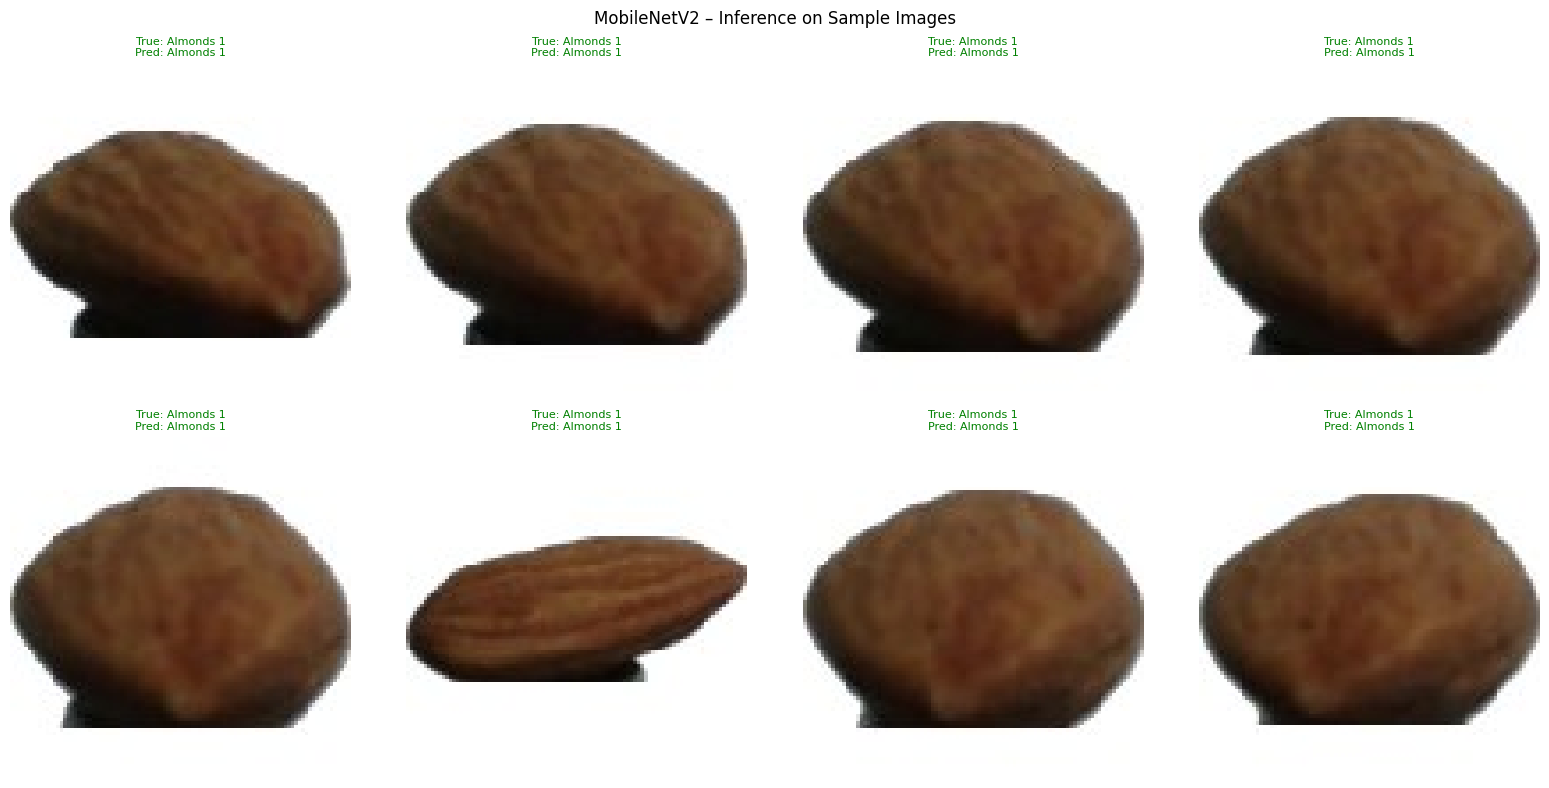


Transfer Learning vs Baseline : +0.30%
Transfer Learning vs Deeper   : +6.14%
Transfer Learning OUTPERFORMS training from scratch on Fruits-360.


In [44]:
tl_test_gen.reset()
tl_loss, tl_acc = tl_model.evaluate(tl_test_gen, verbose=1)
print(f'Transfer Learning Accuracy: {tl_acc*100:.2f}%')
print(f'Transfer Learning Loss    : {tl_loss:.4f}')

tl_test_gen.reset()
y_pred_tl = np.argmax(tl_model.predict(tl_test_gen, verbose=1), axis=1)
y_true_tl = tl_test_gen.classes
tl_labels = list(tl_test_gen.class_indices.keys())
print('\n Classification Report (MobileNetV2 Transfer Learning) ')
print(classification_report(y_true_tl, y_pred_tl, target_names=tl_labels))

# Sample Predictions
tl_test_gen.reset()
sti, stl = next(tl_test_gen)
ptl = tl_model.predict(sti[:8])
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('MobileNetV2 – Inference on Sample Images', fontsize=12)
for i, ax in enumerate(axes.flatten()):
    img = (sti[i] + 1) / 2
    ax.imshow(np.clip(img, 0, 1))
    tl2 = tl_labels[np.argmax(stl[i])]
    pl2 = tl_labels[np.argmax(ptl[i])]
    ax.set_title(f'True: {tl2}\nPred: {pl2}', color='green' if tl2==pl2 else 'red', fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.savefig('/kaggle/working/tl_inference.png', dpi=150)
plt.show()

print(f'\nTransfer Learning vs Baseline : {(tl_acc-baseline_acc)*100:+.2f}%')
print(f'Transfer Learning vs Deeper   : {(tl_acc-deeper_acc)*100:+.2f}%')
if tl_acc > deeper_acc:
    print('Transfer Learning OUTPERFORMS training from scratch on Fruits-360.')
else:
    print('Scratch training performed comparably to Transfer Learning.')

Section 8: Final Comparison & Conclusion

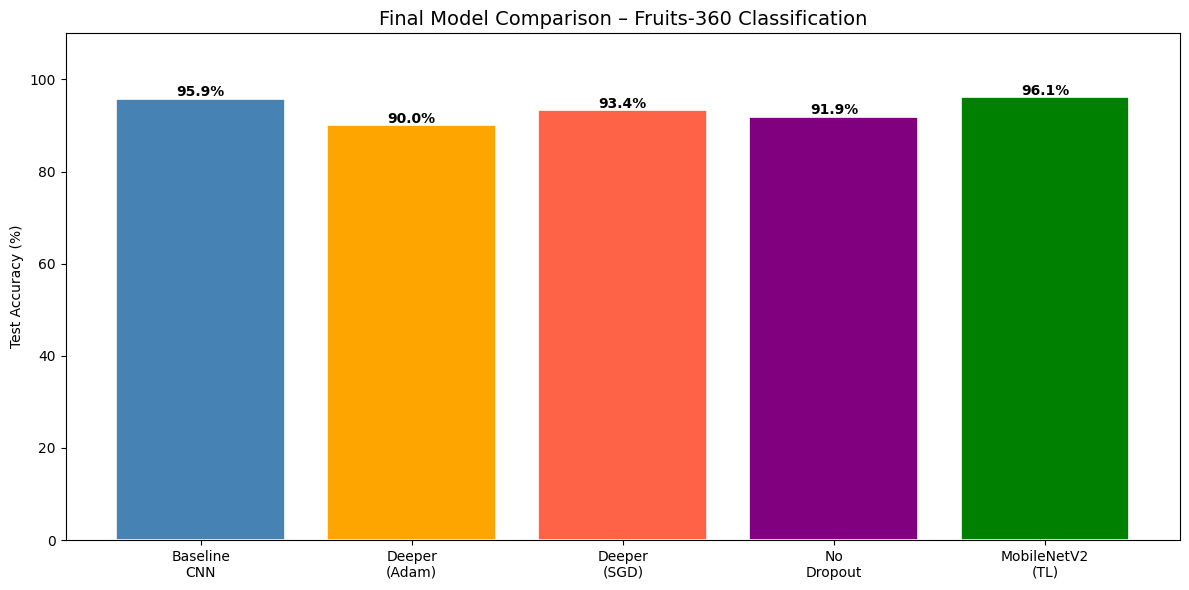

In [45]:
# Final comparison bar chart
model_names = ['Baseline\nCNN', 'Deeper\n(Adam)', 'Deeper\n(SGD)', 'No\nDropout', 'MobileNetV2\n(TL)']
accuracies  = [baseline_acc*100, deeper_acc*100, sgd_acc*100, abl_acc*100, tl_acc*100]
colors      = ['steelblue', 'orange', 'tomato', 'purple', 'green']

plt.figure(figsize=(12, 6))
bars = plt.bar(model_names, accuracies, color=colors, edgecolor='white', linewidth=1.2)
plt.ylabel('Test Accuracy (%)')
plt.title('Final Model Comparison – Fruits-360 Classification', fontsize=14)
plt.ylim(0, 110)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{acc:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/final_comparison.png', dpi=150)
plt.show()

In [46]:
# Final summary table
final_df = pd.DataFrame({
    'Model'          : ['Baseline CNN', 'Deeper (Adam)', 'Deeper (SGD)', 'No Dropout', 'MobileNetV2 (TL)'],
    'Test Acc (%)'   : [round(baseline_acc*100,2), round(deeper_acc*100,2),
                        round(sgd_acc*100,2),       round(abl_acc*100,2), round(tl_acc*100,2)],
    'Test Loss'      : [round(baseline_loss,4), round(deeper_loss,4),
                        round(sgd_loss,4),       round(abl_loss,4), round(tl_loss,4)],
    'Train Time(min)': [round(baseline_train_time/60,1), round(deeper_adam_time/60,1),
                        round(deeper_sgd_time/60,1), 'N/A', round((tl_p1_time+tl_p2_time)/60,1)]
})
print(' FINAL MODEL SUMMARY ')
print(final_df.to_string(index=False))

 FINAL MODEL SUMMARY 
           Model  Test Acc (%)  Test Loss Train Time(min)
    Baseline CNN         95.85     0.7826            64.9
   Deeper (Adam)         90.01     0.6781            52.9
    Deeper (SGD)         93.37     0.5426            60.2
      No Dropout         91.93     0.6642             N/A
MobileNetV2 (TL)         96.15     0.4617           148.3


In [47]:
# Save all models
baseline_model.save('/kaggle/working/baseline_cnn.keras')
deeper_model.save('/kaggle/working/deeper_cnn_adam.keras')
tl_model.save('/kaggle/working/mobilenetv2_transfer.keras')
print('All models saved to /kaggle/working/')

All models saved to /kaggle/working/
